# Parametric PINN: 2D Shockwave Propagation varying Fluid Density

This notebook implements a **Parametric Surrogate Model** using a Physics-Informed Neural Network. We model a 2D explosion (blast wave propagation) from the center of the domain.

Instead of training a model for a single physical scenario, we introduce the **fluid density $\rho$** as an additional input feature. The model learns the entire physical envelope and acts as a real-time surrogate solver.

### The Governing PDE
We use the 2D Wave Equation (linearized Euler for acoustic shock propagation):
$$ \frac{\partial^2 p}{\partial t^2} = c^2 \left( \frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} \right) $$

Where the wave speed $c$ depends on the medium's density $\rho$ (assuming unit bulk modulus $K=1$): $c = \frac{1}{\sqrt{\rho}}$.
* **Higher $\rho$** $\rightarrow$ Slower shockwave.
* **Lower $\rho$** $\rightarrow$ Faster shockwave.

**Domain & Conditions:**
* Space: $x, y \in [-1, 1]$
* Time: $t \in [0, 1]$
* Density envelope: $\rho \in [1.0, 4.0]$
* Initial Condition (Explosion): $p(x,y,0) = e^{-\frac{x^2+y^2}{0.02}}$ (a Gaussian pressure peak at the center).
* Initial Velocity: $p_t(x,y,0) = 0$.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Dispositivo in uso: {device}")

🚀 Dispositivo in uso: cuda


In [2]:
class Parametric_PINN_2D(nn.Module):
    def __init__(self):
        super(Parametric_PINN_2D, self).__init__()
        # INPUTS: [x, y, t, rho] -> 4 features
        # OUTPUT: [p] (Pressure anomaly) -> 1 feature
        self.net = nn.Sequential(
            nn.Linear(4, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x, y, t, rho):
        return self.net(torch.cat([x, y, t, rho], dim=1))

In [3]:
def wave_loss(model, x, y, t, rho):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    
    # Previsione della pressione
    p = model(x, y, t, rho)
    
    # Derivate prime
    p_t = torch.autograd.grad(p, t, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    
    # Derivate seconde
    p_tt = torch.autograd.grad(p_t, t, grad_outputs=torch.ones_like(p_t), create_graph=True)[0]
    p_xx = torch.autograd.grad(p_x, x, grad_outputs=torch.ones_like(p_x), create_graph=True)[0]
    p_yy = torch.autograd.grad(p_y, y, grad_outputs=torch.ones_like(p_y), create_graph=True)[0]
    
    # Equazione d'onda parametrica: p_tt = (1/rho) * (p_xx + p_yy)
    c_squared = 1.0 / rho
    pde_residual = p_tt - c_squared * (p_xx + p_yy)
    
    return torch.mean(pde_residual**2)

In [4]:
N_pde = 15000  # Punti interni per la PDE
N_ic = 3000    # Condizioni iniziali
N_bc = 3000    # Bordi
rho_min, rho_max = 1.0, 4.0

# 1. Punti PDE (Spazio, tempo e DENSITA' casuali)
x_pde = (torch.rand(N_pde, 1) * 2 - 1).to(device)
y_pde = (torch.rand(N_pde, 1) * 2 - 1).to(device)
t_pde = torch.rand(N_pde, 1).to(device)
rho_pde = (torch.rand(N_pde, 1) * (rho_max - rho_min) + rho_min).to(device)

# 2. Condizioni Iniziali (t=0, l'esplosione gaussiana al centro)
x_ic = (torch.rand(N_ic, 1) * 2 - 1).to(device)
y_ic = (torch.rand(N_ic, 1) * 2 - 1).to(device)
t_ic = torch.zeros(N_ic, 1).to(device)
rho_ic = (torch.rand(N_ic, 1) * (rho_max - rho_min) + rho_min).to(device)
# Gaussiana stretta (picco di pressione 1.0 al centro x=0, y=0)
p_ic_true = torch.exp(-(x_ic**2 + y_ic**2) / 0.02).to(device)

# 3. Condizioni al Contorno (Bordi a pressione zero)
x_bc = torch.cat([-torch.ones(N_bc//4, 1), torch.ones(N_bc//4, 1), torch.rand(N_bc//2, 1)*2-1]).to(device)
y_bc = torch.cat([torch.rand(N_bc//2, 1)*2-1, -torch.ones(N_bc//4, 1), torch.ones(N_bc//4, 1)]).to(device)
t_bc = torch.rand(N_bc, 1).to(device)
rho_bc = (torch.rand(N_bc, 1) * (rho_max - rho_min) + rho_min).to(device)
p_bc_true = torch.zeros(N_bc, 1).to(device)

In [5]:
model = Parametric_PINN_2D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 3000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Loss della PDE
    loss_pde = wave_loss(model, x_pde, y_pde, t_pde, rho_pde)
    
    # 2. Loss Condizione Iniziale (Posizione dell'urto)
    p_ic_pred = model(x_ic, y_ic, t_ic, rho_ic)
    loss_ic_1 = torch.mean((p_ic_pred - p_ic_true)**2)
    
    # 3. Loss Condizione Iniziale 2 (Velocità iniziale nulla)
    # Calcoliamo la derivata al tempo zero per forzarla a 0
    t_ic.requires_grad_(True)
    p_ic_pred_for_grad = model(x_ic, y_ic, t_ic, rho_ic)
    p_t_ic = torch.autograd.grad(p_ic_pred_for_grad, t_ic, grad_outputs=torch.ones_like(p_ic_pred_for_grad), create_graph=True)[0]
    loss_ic_2 = torch.mean(p_t_ic**2)
    
    # 4. Loss Bordi
    loss_bc = torch.mean((model(x_bc, y_bc, t_bc, rho_bc) - p_bc_true)**2)
    
    # LOSS TOTALE
    loss = loss_pde + loss_ic_1 + loss_ic_2 + loss_bc
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {loss.item():.5f} | PDE: {loss_pde.item():.5f}")

print("Addestramento del Modello Surrogato completato!")

c:\Users\aless\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch    0 | Total Loss: 0.00999 | PDE: 0.00002
Epoch  500 | Total Loss: 0.00696 | PDE: 0.00005
Epoch 1000 | Total Loss: 0.00653 | PDE: 0.00016
Epoch 1500 | Total Loss: 0.00552 | PDE: 0.00031
Epoch 2000 | Total Loss: 0.00370 | PDE: 0.00046
Epoch 2500 | Total Loss: 0.00255 | PDE: 0.00059
Addestramento del Modello Surrogato completato!


Generazione dell'animazione Split-Screen...


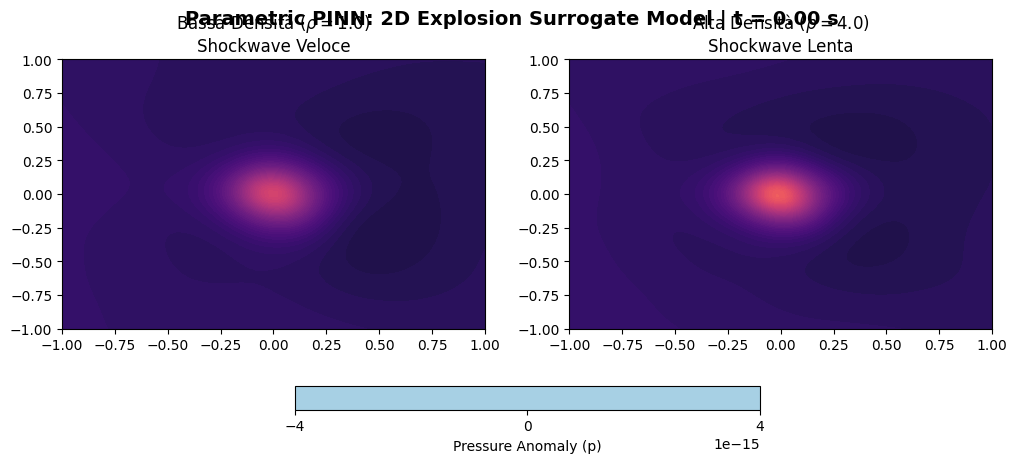

In [6]:
# Creiamo una griglia 2D spaziale 60x60
grid_points = 60
x_test = torch.linspace(-1, 1, grid_points)
y_test = torch.linspace(-1, 1, grid_points)
X, Y = torch.meshgrid(x_test, y_test, indexing='ij')

X_flat = X.reshape(-1, 1).to(device)
Y_flat = Y.reshape(-1, 1).to(device)

# Creiamo due tensori per la densità: Uno per rho=1.0, uno per rho=4.0
rho_low = (torch.ones_like(X_flat) * 1.0).to(device)
rho_high = (torch.ones_like(X_flat) * 4.0).to(device)

# Configurazione del grafico Split-Screen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cax1 = ax1.contourf(X.numpy(), Y.numpy(), np.zeros((grid_points, grid_points)), 50, cmap='RdBu_r', vmin=-0.5, vmax=1.0)
cax2 = ax2.contourf(X.numpy(), Y.numpy(), np.zeros((grid_points, grid_points)), 50, cmap='RdBu_r', vmin=-0.5, vmax=1.0)

fig.colorbar(cax1, ax=[ax1, ax2], label='Pressure Anomaly (p)', location='bottom', shrink=0.5)

def update(frame):
    t_val = frame / 30.0  # Animazione da 0 a 1 secondo in 30 frame
    T_flat = (torch.ones_like(X_flat) * t_val).to(device)
    
    with torch.no_grad():
        # INFERENZA 1: Bassa Densità
        p_low = model(X_flat, Y_flat, T_flat, rho_low).cpu().numpy().reshape(grid_points, grid_points)
        # INFERENZA 2: Alta Densità
        p_high = model(X_flat, Y_flat, T_flat, rho_high).cpu().numpy().reshape(grid_points, grid_points)
        
    ax1.clear()
    ax2.clear()
    
    ax1.contourf(X.numpy(), Y.numpy(), p_low, 50, cmap='magma', vmin=-0.2, vmax=1.0)
    ax2.contourf(X.numpy(), Y.numpy(), p_high, 50, cmap='magma', vmin=-0.2, vmax=1.0)
    
    ax1.set_title(rf'Bassa Densità ($\rho = 1.0$)' + '\nShockwave Veloce')
    ax2.set_title(rf'Alta Densità ($\rho = 4.0$)' + '\nShockwave Lenta')
    
    fig.suptitle(f'Parametric PINN: 2D Explosion Surrogate Model | t = {t_val:.2f} s', fontsize=14, fontweight='bold')
    
    return ax1, ax2

print("Generazione dell'animazione Split-Screen...")
ani = animation.FuncAnimation(fig, update, frames=30, interval=150, blit=False)
ani.save('parametric_2d_explosion.gif', writer='pillow', fps=10)

HTML(ani.to_jshtml())